In [0]:
import pandas as pd

In [0]:
df= spark.read.csv('/Volumes/workspace/default/depre/depression_data.csv', header=True)

display(df)

Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes
Kathy Hill,20,Single,High School,0,Former,Active,Employed,44448.91,Low,Unhealthy,Fair,No,Yes,No,No
Crystal Delgado,60,Widowed,Associate Degree,1,Non-smoker,Sedentary,Unemployed,22565.47,Moderate,Moderate,Poor,No,Yes,No,No
Charles Kaiser,31,Single,High School,0,Non-smoker,Active,Employed,39608.18,Moderate,Unhealthy,Good,No,No,No,No
Kathryn Taylor,50,Divorced,Bachelor's Degree,0,Non-smoker,Active,Employed,93360.07,Moderate,Healthy,Good,No,Yes,No,Yes
Alexander Hernandez,77,Married,Bachelor's Degree,2,Non-smoker,Sedentary,Employed,77597.84,Low,Unhealthy,Poor,Yes,No,No,No


In [0]:
df.dtypes

[('Name', 'string'),
 ('Age', 'string'),
 ('Marital Status', 'string'),
 ('Education Level', 'string'),
 ('Number of Children', 'string'),
 ('Smoking Status', 'string'),
 ('Physical Activity Level', 'string'),
 ('Employment Status', 'string'),
 ('Income', 'string'),
 ('Alcohol Consumption', 'string'),
 ('Dietary Habits', 'string'),
 ('Sleep Patterns', 'string'),
 ('History of Mental Illness', 'string'),
 ('History of Substance Abuse', 'string'),
 ('Family History of Depression', 'string'),
 ('Chronic Medical Conditions', 'string')]

In [0]:
df.count()

413768

In [0]:
df.dropDuplicates().count()

413768

In [0]:
categorical_cols = ["Marital Status", "Education Level", "Smoking Status", 
                     "Physical Activity Level", "Employment Status", 
                     "Alcohol Consumption", "Dietary Habits", "Sleep Patterns",
                     "History of Mental Illness", "History of Substance Abuse",
                     "Family History of Depression", "Chronic Medical Conditions"]

for c in categorical_cols:
    print(f"--- {c} ---")
    df.select(c).distinct().show(truncate=False)

--- Marital Status ---
+--------------+
|Marital Status|
+--------------+
|Widowed       |
|Divorced      |
|Single        |
|Married       |
+--------------+

--- Education Level ---
+-----------------+
|Education Level  |
+-----------------+
|Bachelor's Degree|
|Associate Degree |
|High School      |
|Master's Degree  |
|PhD              |
+-----------------+

--- Smoking Status ---
+--------------+
|Smoking Status|
+--------------+
|Current       |
|Former        |
|Non-smoker    |
+--------------+

--- Physical Activity Level ---
+-----------------------+
|Physical Activity Level|
+-----------------------+
|Moderate               |
|Sedentary              |
|Active                 |
+-----------------------+

--- Employment Status ---
+-----------------+
|Employment Status|
+-----------------+
|Unemployed       |
|Employed         |
+-----------------+

--- Alcohol Consumption ---
+-------------------+
|Alcohol Consumption|
+-------------------+
|High               |
|Moderate     

In [0]:
from pyspark.sql.functions import col
df.select("Age", "Income", "Number of Children").describe().show()

# Flag impossible values explicitly
df.filter(col("Income").cast("double") < 0).show()
df.filter((col("Age").cast("int") < 0) | (col("Age").cast("int") > 110)).show()
df.filter(col("Number of Children").cast("int") < 0).show()

+-------+------------------+------------------+------------------+
|summary|               Age|            Income|Number of Children|
+-------+------------------+------------------+------------------+
|  count|            413768|            413768|            413768|
|   mean| 49.00071295991957|50661.707971302756|1.2989718876278493|
| stddev|18.158759370459084| 40624.10056474354|1.2370539679549237|
|    min|                18|              0.41|                 0|
|    max|                80|          99999.75|                 4|
+-------+------------------+------------------+------------------+

+----+---+--------------+---------------+------------------+--------------+-----------------------+-----------------+------+-------------------+--------------+--------------+-------------------------+--------------------------+----------------------------+--------------------------+
|Name|Age|Marital Status|Education Level|Number of Children|Smoking Status|Physical Activity Level|Employment St

In [0]:
#df["Age"] = df["Age"].astype(int)
#df["Number of Children"] = df["Number of Children"].astype(int)
#df["Income"] = df["Income"].astype(float)

from pyspark.sql.types import IntegerType, DoubleType

df = df.withColumn("Age", col("Age").cast(IntegerType())) \
       .withColumn("Number of Children", col("Number of Children").cast(IntegerType())) \
       .withColumn("Income", col("Income").cast(DoubleType()))

df.printSchema()

root
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Marital Status: string (nullable = true)
 |-- Education Level: string (nullable = true)
 |-- Number of Children: integer (nullable = true)
 |-- Smoking Status: string (nullable = true)
 |-- Physical Activity Level: string (nullable = true)
 |-- Employment Status: string (nullable = true)
 |-- Income: double (nullable = true)
 |-- Alcohol Consumption: string (nullable = true)
 |-- Dietary Habits: string (nullable = true)
 |-- Sleep Patterns: string (nullable = true)
 |-- History of Mental Illness: string (nullable = true)
 |-- History of Substance Abuse: string (nullable = true)
 |-- Family History of Depression: string (nullable = true)
 |-- Chronic Medical Conditions: string (nullable = true)



In [0]:
from pyspark.sql.functions import col, sum as spark_sum, when

# Null counts per column
df.select([spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]).show()

# Min/max for numeric columns
df.select("Age", "Number of Children", "Income").describe().show()

+----+---+--------------+---------------+------------------+--------------+-----------------------+-----------------+------+-------------------+--------------+--------------+-------------------------+--------------------------+----------------------------+--------------------------+
|Name|Age|Marital Status|Education Level|Number of Children|Smoking Status|Physical Activity Level|Employment Status|Income|Alcohol Consumption|Dietary Habits|Sleep Patterns|History of Mental Illness|History of Substance Abuse|Family History of Depression|Chronic Medical Conditions|
+----+---+--------------+---------------+------------------+--------------+-----------------------+-----------------+------+-------------------+--------------+--------------+-------------------------+--------------------------+----------------------------+--------------------------+
|   0|  0|             0|              0|                 0|             0|                      0|                0|     0|                  0|    

In [0]:
df.count() 

df.dropDuplicates().count()

413768

In [0]:
df.groupBy("History of Mental Illness").count().show()

+-------------------------+------+
|History of Mental Illness| count|
+-------------------------+------+
|                       No|287943|
|                      Yes|125825|
+-------------------------+------+



In [0]:
pdf = df.toPandas()

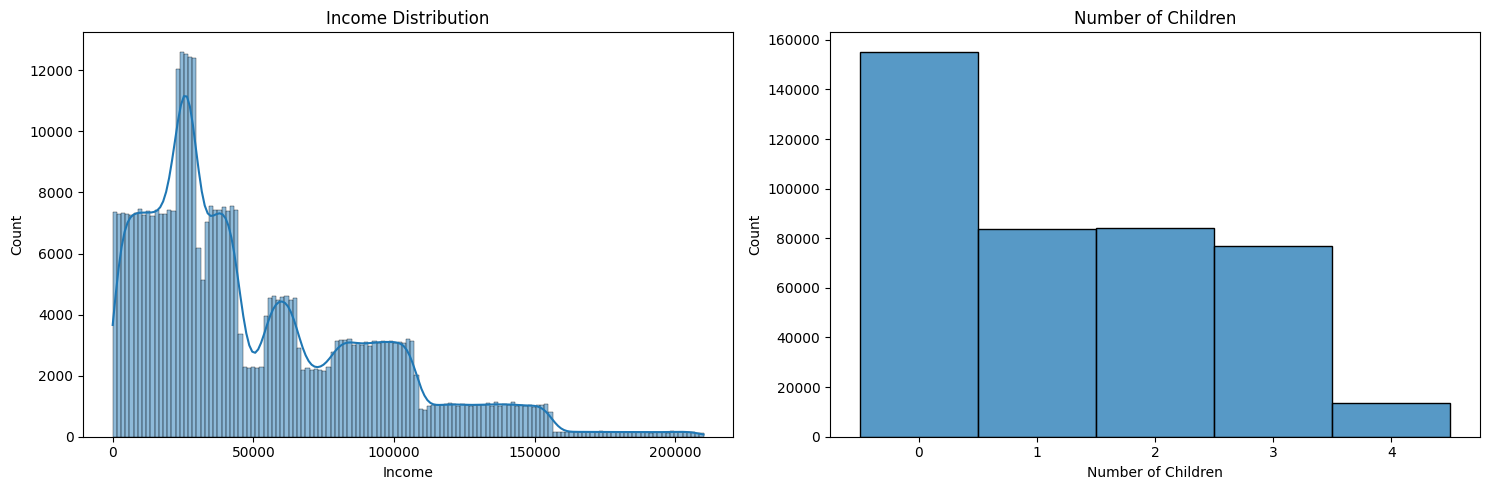

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(pdf["Income"], kde=True, ax=axes[0]).set_title("Income Distribution")
sns.histplot(pdf["Number of Children"], discrete=True, ax=axes[1]).set_title("Number of Children")
plt.tight_layout()
plt.show()

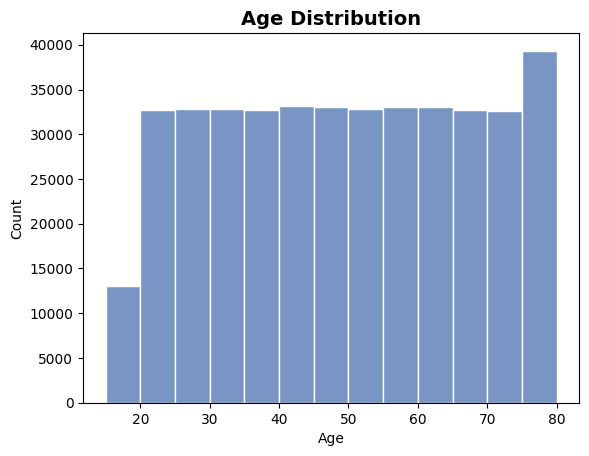

In [0]:
sns.histplot(pdf["Age"], bins=range(15, 85, 5), color="#4C72B0", edgecolor="white")
plt.title("Age Distribution", fontsize=14, weight="bold")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

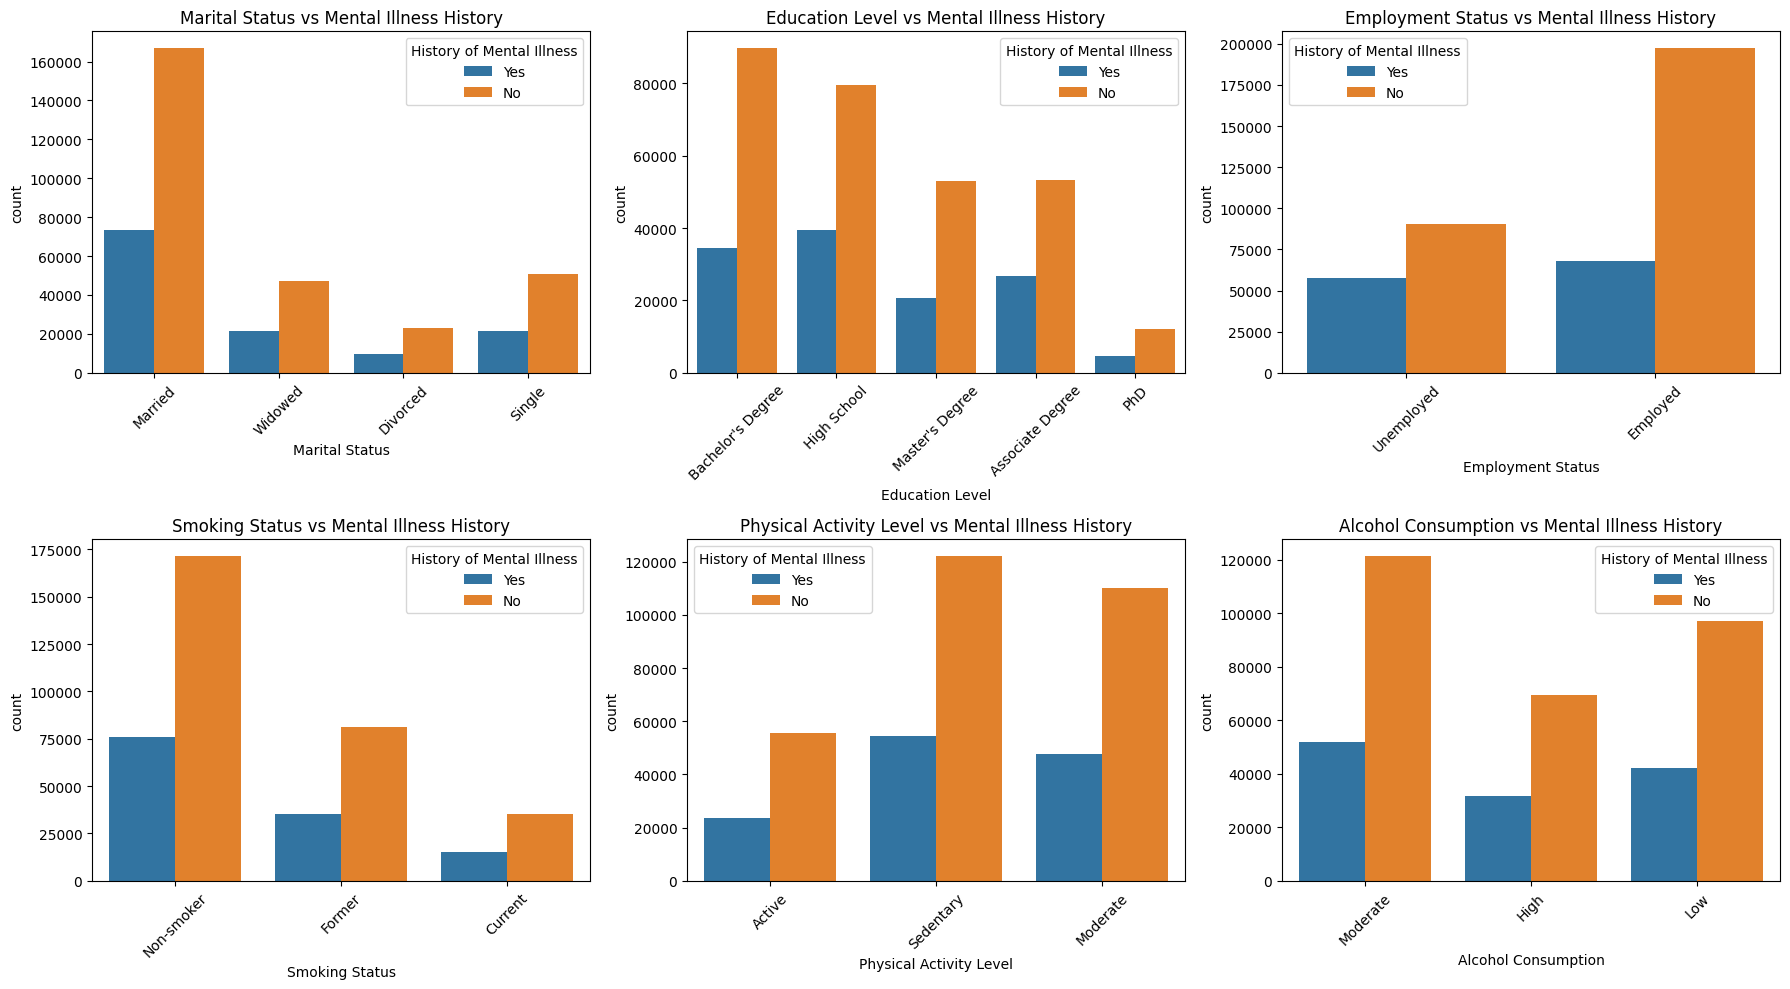

In [0]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_cols = ["Marital Status", "Education Level", "Employment Status",
            "Smoking Status", "Physical Activity Level", "Alcohol Consumption"]

for ax, colname in zip(axes.flatten(), cat_cols):
    sns.countplot(data=pdf, x=colname, hue="History of Mental Illness", ax=ax)
    ax.set_title(f"{colname} vs Mental Illness History")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

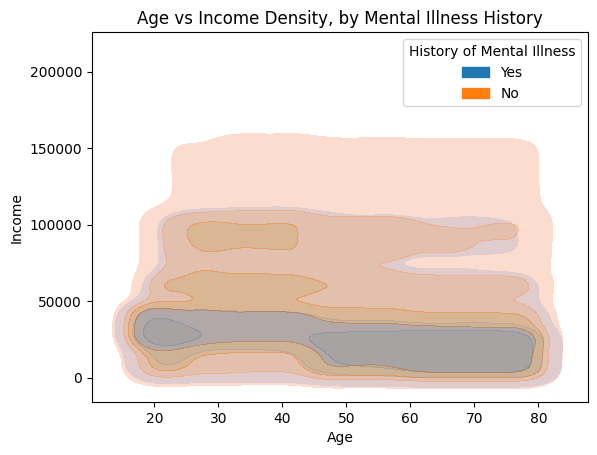

In [0]:
sns.kdeplot(data=pdf, x="Age", y="Income", hue="History of Mental Illness", 
            fill=True, alpha=0.4, levels=5)
plt.title("Age vs Income Density, by Mental Illness History")
plt.show()

/home/spark-e3caaea3-4f34-4031-a16c-31/.ipykernel/75/command-7250015227937839-3660674219:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = pdf.groupby("Age Group")["History of Mental Illness"].value_counts(normalize=True).unstack()


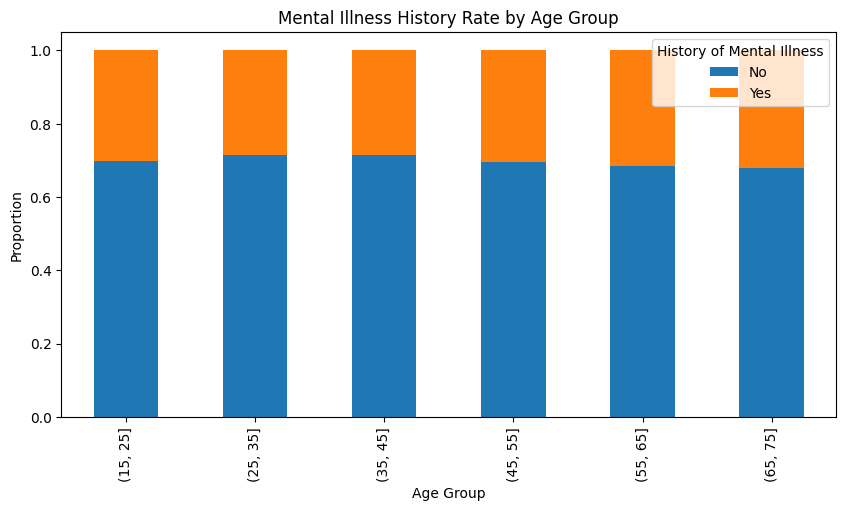

In [0]:
pdf["Age Group"] = pd.cut(pdf["Age"], bins=range(15, 85, 10))
rate = pdf.groupby("Age Group")["History of Mental Illness"].value_counts(normalize=True).unstack()
rate.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Mental Illness History Rate by Age Group")
plt.ylabel("Proportion")
plt.show()

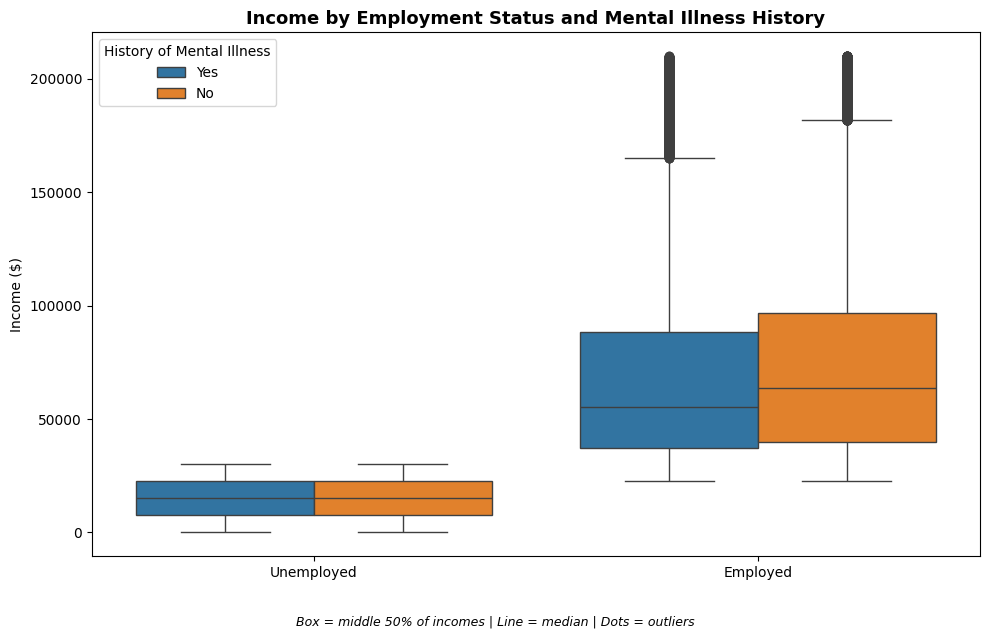

In [0]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=pdf, x="Employment Status", y="Income", hue="History of Mental Illness")
plt.title("Income by Employment Status and Mental Illness History", fontsize=13, weight="bold")
plt.ylabel("Income ($)")
plt.xlabel("")
plt.figtext(0.5, -0.05, "Box = middle 50% of incomes | Line = median | Dots = outliers", 
            ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

In [0]:
# Aggregate in Spark
counts = df.groupBy("Family History of Depression", "History of Mental Illness").count()
counts_pdf = counts.toPandas()

# Pivot into a clean grid: rows = Family History, columns = Mental Illness History
pivot = counts_pdf.pivot(index="Family History of Depression", 
                          columns="History of Mental Illness", 
                          values="count")

print(pivot)

History of Mental Illness         No    Yes
Family History of Depression               
No                            210934  91581
Yes                            77009  34244


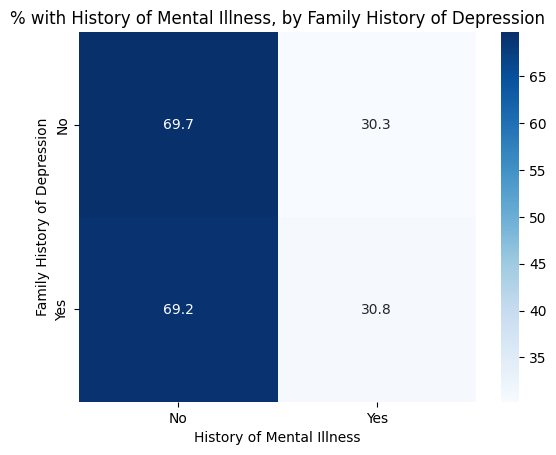

In [0]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("% with History of Mental Illness, by Family History of Depression")
plt.show()

## Prediction Modelling for History of Mental Illness

In [0]:
# Pull full dataset to pandas
pdf = df.toPandas()

from sklearn.preprocessing import LabelEncoder

# Drop Name — not useful for correlation
pdf_corr = pdf.drop(columns=["Name"])

# Encode every categorical (object/string) column to numeric
le = LabelEncoder()
pdf_encoded = pdf_corr.copy()
for c in pdf_encoded.columns:
    if pdf_encoded[c].dtype == "object":
        pdf_encoded[c] = le.fit_transform(pdf_encoded[c].astype(str))

# Full correlation matrix
corr = pdf_encoded.corr()

In [0]:
target_corr = corr["History of Mental Illness"].sort_values(ascending=False)
print(target_corr)

History of Mental Illness       1.000000
Employment Status               0.140764
Dietary Habits                  0.027351
Age                             0.024683
Sleep Patterns                  0.016362
Physical Activity Level         0.008566
Marital Status                  0.007178
Chronic Medical Conditions      0.006038
Smoking Status                  0.005256
Family History of Depression    0.004887
Number of Children              0.002713
History of Substance Abuse      0.001733
Alcohol Consumption            -0.012422
Education Level                -0.018947
Income                         -0.136805
Name: History of Mental Illness, dtype: float64


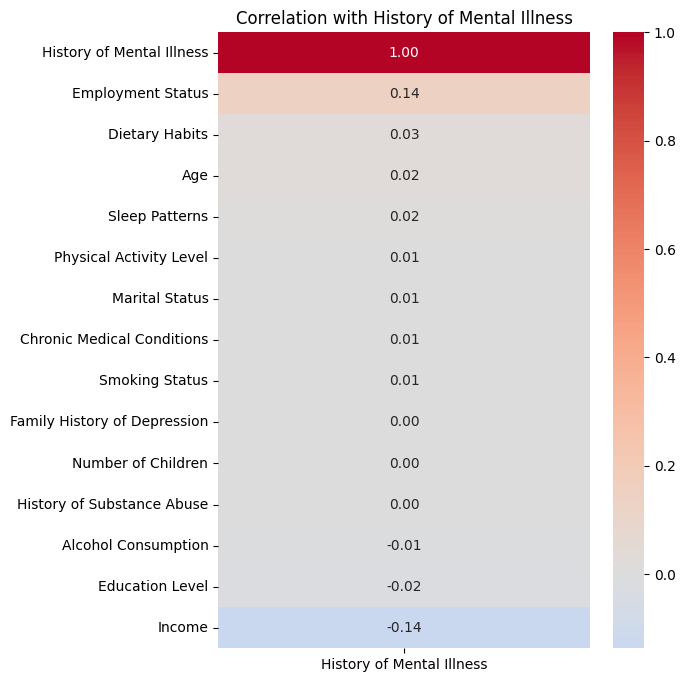

In [0]:
plt.figure(figsize=(6, 8))
sns.heatmap(target_corr.to_frame(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with History of Mental Illness")
plt.show()

In [0]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

pdf_model = pdf.drop(columns=["Name"]).copy()

# Encode categoricals (including target)
le_dict = {}
for c in pdf_model.columns:
    if pdf_model[c].dtype == "object":
        le = LabelEncoder()
        pdf_model[c] = le.fit_transform(pdf_model[c].astype(str))
        le_dict[c] = le

X = pdf_model.drop(columns=["History of Mental Illness"])
y = pdf_model["History of Mental Illness"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [0]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, f1_score

In [0]:
# from sklearn.linear_model import LogisticRegression

# Run 1: RandomizedSearchCV, broad exploration
log_params_1 = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"],
    "max_iter": [500, 1000, 2000]
}
log_run1 = RandomizedSearchCV(LogisticRegression(), log_params_1, n_iter=20, cv=5, 
                                scoring="f1", n_jobs=-1, random_state=42)
log_run1.fit(X_train, y_train)

# Run 2: GridSearchCV, narrower/different grid
log_params_2 = {
    "C": [0.05, 0.5, 5, 50],
    "penalty": ["l2"],
    "solver": ["lbfgs", "newton-cg"],
    "class_weight": [None, "balanced"],
    "tol": [1e-4, 1e-3]
}
log_run2 = GridSearchCV(LogisticRegression(max_iter=1000), log_params_2, cv=5, 
                          scoring="f1", n_jobs=-1)
log_run2.fit(X_train, y_train)

# Pick the winner between the two runs
log_best = log_run1 if log_run1.best_score_ >= log_run2.best_score_ else log_run2
print("Run 1 best F1:", log_run1.best_score_, log_run1.best_params_)
print("Run 2 best F1:", log_run2.best_score_, log_run2.best_params_)
print("Logistic Regression winner:", log_best.best_params_)

/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: Con

Run 1 best F1: 0.44836126348325445 {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'class_weight': 'balanced', 'C': 0.1}
Run 2 best F1: 0.42947735636716067 {'C': 0.05, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg', 'tol': 0.001}
Logistic Regression winner: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'class_weight': 'balanced', 'C': 0.1}


In [0]:
from sklearn.ensemble import RandomForestClassifier

# Run 1: RandomizedSearchCV, wide range
rf_params_1 = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}
rf_run1 = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params_1, 
                               n_iter=20, cv=3, scoring="f1", n_jobs=-1, random_state=42)
rf_run1.fit(X_train, y_train)

# Run 2: RandomizedSearchCV, different range/seed for a distinct search path
rf_params_2 = {
    "n_estimators": [150, 250, 400],
    "max_depth": [15, 25, 35, None],
    "min_samples_split": [4, 8, 15],
    "min_samples_leaf": [2, 3, 5],
    "max_features": ["sqrt", 0.5, 0.8],
    "class_weight": ["balanced", "balanced_subsample"]
}
rf_run2 = RandomizedSearchCV(RandomForestClassifier(random_state=7), rf_params_2, 
                               n_iter=20, cv=3, scoring="f1", n_jobs=-1, random_state=7)
rf_run2.fit(X_train, y_train)

rf_best = rf_run1 if rf_run1.best_score_ >= rf_run2.best_score_ else rf_run2
print("Run 1 best F1:", rf_run1.best_score_, rf_run1.best_params_)
print("Run 2 best F1:", rf_run2.best_score_, rf_run2.best_params_)
print("Random Forest winner:", rf_best.best_params_)

/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
I0000 00:00:1789471750.972168     694 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers


/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Run 1 best F1: 0.4359348402919763 {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced'}
Run 2 best F1: 0.4313801162031808 {'n_estimators': 400, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 0.8, 'max_depth': 15, 'class_weight': 'balanced_subsample'}
Random Forest winner: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced'}


In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from xgboost import XGBClassifier

# Run 1: RandomizedSearchCV, broad
xgb_params_1 = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5]
}
xgb_run1 = RandomizedSearchCV(XGBClassifier(eval_metric="logloss", random_state=42), 
                                xgb_params_1, n_iter=20, cv=3, scoring="f1", n_jobs=-1, random_state=42)
xgb_run1.fit(X_train, y_train)

# Run 2: different search path/ranges
xgb_params_2 = {
    "n_estimators": [150, 250, 400],
    "max_depth": [4, 6, 8, 12],
    "learning_rate": [0.03, 0.08, 0.15],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_alpha": [0, 0.5, 1]
}
xgb_run2 = RandomizedSearchCV(XGBClassifier(eval_metric="logloss", random_state=7), 
                                xgb_params_2, n_iter=20, cv=3, scoring="f1", n_jobs=-1, random_state=7)
xgb_run2.fit(X_train, y_train)

xgb_best = xgb_run1 if xgb_run1.best_score_ >= xgb_run2.best_score_ else xgb_run2
print("Run 1 best F1:", xgb_run1.best_score_, xgb_run1.best_params_)
print("Run 2 best F1:", xgb_run2.best_score_, xgb_run2.best_params_)
print("XGBoost winner:", xgb_best.best_params_)

Run 1 best F1: 0.10890506527246206 {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Run 2 best F1: 0.147288575263691 {'subsample': 1.0, 'reg_alpha': 0.5, 'n_estimators': 150, 'max_depth': 12, 'learning_rate': 0.15, 'colsample_bytree': 0.7}
XGBoost winner: {'subsample': 1.0, 'reg_alpha': 0.5, 'n_estimators': 150, 'max_depth': 12, 'learning_rate': 0.15, 'colsample_bytree': 0.7}


In [0]:
final_models = {
    "Logistic Regression": log_best.best_estimator_,
    "Random Forest": rf_best.best_estimator_,
    "XGBoost": xgb_best.best_estimator_
}

results = []
for name, model in final_models.items():
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    results.append((name, f1))

results_df = pd.DataFrame(results, columns=["Model", "Test F1"]).sort_values("Test F1", ascending=False)
print("\nFinal ranking:\n", results_df)


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.75      0.55      0.63     57589
           1       0.36      0.58      0.45     25165

    accuracy                           0.56     82754
   macro avg       0.56      0.57      0.54     82754
weighted avg       0.63      0.56      0.58     82754


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.75      0.64      0.69     57589
           1       0.38      0.50      0.43     25165

    accuracy                           0.60     82754
   macro avg       0.56      0.57      0.56     82754
weighted avg       0.63      0.60      0.61     82754


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.70      0.94      0.80     57589
           1       0.37      0.07      0.12     25165

    accuracy                           0.68     82754
   macro avg       0.53      0.51      0.46     82754
weigh

In [0]:
# Pick out the winning model name and object from your final comparison
best_model_name = results_df.iloc[0]["Model"]
best_model = final_models[best_model_name]

print(f"Best model: {best_model_name}")

Best model: Logistic Regression


In [0]:
y_best_pred = best_model.predict(X_test)

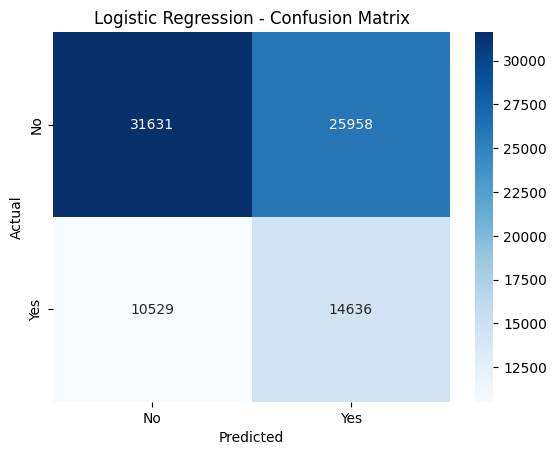

In [0]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [0]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_best_pred, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.75      0.55      0.63     57589
         Yes       0.36      0.58      0.45     25165

    accuracy                           0.56     82754
   macro avg       0.56      0.57      0.54     82754
weighted avg       0.63      0.56      0.58     82754



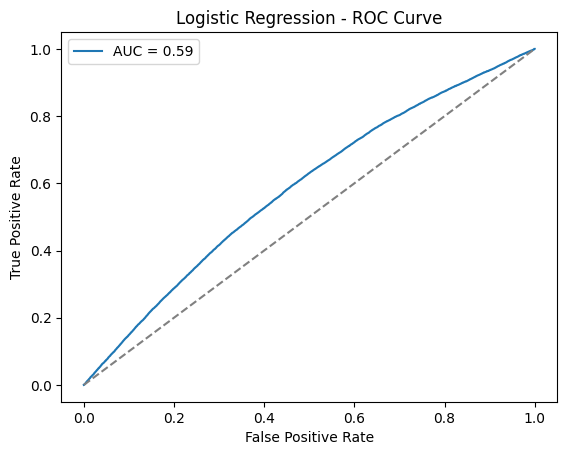

In [0]:
from sklearn.metrics import roc_curve, auc

y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{best_model_name} - ROC Curve")
plt.legend()
plt.show()

In [0]:
dbutils.widgets.removeAll()

dbutils.widgets.text("Age", "30")
dbutils.widgets.text("Income", "50000")
dbutils.widgets.text("Number of Children", "0")
dbutils.widgets.dropdown("Marital Status", "Married", ["Married", "Single", "Divorced", "Widowed"])
dbutils.widgets.dropdown("Education Level", "Bachelor's Degree", ["High School", "Associate Degree", "Bachelor's Degree", "Master's Degree", "PhD"])
dbutils.widgets.dropdown("Smoking Status", "Non-smoker", ["Non-smoker", "Former", "Active"])
dbutils.widgets.dropdown("Physical Activity Level", "Moderate", ["Low", "Moderate", "High"])
dbutils.widgets.dropdown("Employment Status", "Employed", ["Employed", "Unemployed"])
dbutils.widgets.dropdown("Alcohol Consumption", "Moderate", ["Low", "Moderate", "High"])
dbutils.widgets.dropdown("Dietary Habits", "Moderate", ["Unhealthy", "Moderate", "Healthy"])
dbutils.widgets.dropdown("Sleep Patterns", "Fair", ["Poor", "Fair", "Good"])
dbutils.widgets.dropdown("History of Substance Abuse", "No", ["Yes", "No"])
dbutils.widgets.dropdown("Family History of Depression", "No", ["Yes", "No"])
dbutils.widgets.dropdown("Chronic Medical Conditions", "No", ["Yes", "No"])

In [0]:
def get_widget_inputs():
    return {
        "Age": int(dbutils.widgets.get("Age")),
        "Income": float(dbutils.widgets.get("Income")),
        "Number of Children": int(dbutils.widgets.get("Number of Children")),
        "Marital Status": dbutils.widgets.get("Marital Status"),
        "Education Level": dbutils.widgets.get("Education Level"),
        "Smoking Status": dbutils.widgets.get("Smoking Status"),
        "Physical Activity Level": dbutils.widgets.get("Physical Activity Level"),
        "Employment Status": dbutils.widgets.get("Employment Status"),
        "Alcohol Consumption": dbutils.widgets.get("Alcohol Consumption"),
        "Dietary Habits": dbutils.widgets.get("Dietary Habits"),
        "Sleep Patterns": dbutils.widgets.get("Sleep Patterns"),
        "History of Substance Abuse": dbutils.widgets.get("History of Substance Abuse"),
        "Family History of Depression": dbutils.widgets.get("Family History of Depression"),
        "Chronic Medical Conditions": dbutils.widgets.get("Chronic Medical Conditions"),
    }

def predict_from_inputs(inputs_dict):
    row = pd.DataFrame([inputs_dict])
    
    # Encode categoricals using the SAME encoders fit during training
    for c in row.columns:
        if c in le_dict:
            row[c] = le_dict[c].transform(row[c].astype(str))
    
    # Match column order to training data
    row = row[X_train.columns]
    
    pred = best_model.predict(row)[0]
    proba = best_model.predict_proba(row)[0][1]  # probability of "Yes"
    
    label = "Yes" if pred == 1 else "No"
    print(f"Predicted History of Mental Illness: {label}")
    print(f"Model confidence (probability of Yes): {proba:.2%}")

# Run the prediction
inputs = get_widget_inputs()
predict_from_inputs(inputs)

Predicted History of Mental Illness: No
Model confidence (probability of Yes): 46.09%
